In [1]:
# loading the AirQo standardised dataset
import pandas as pd;
import numpy as np;

# load the data
data = pd.read_json(r"E:\RSXS\Study\project\ParticulateMatterApp\data\ML\standardised_airqo.json");
print(data.head());
print("\nShape:");
print(data.shape);

print("\nColumns:");
print(data.columns);

                       hour   pm25  temperature  humidity  \
0  2026-07-03T06:00:00.000Z  18.35        24.47     73.09   
1  2026-07-03T07:00:00.000Z  46.08        27.35     66.01   
2  2026-07-03T08:00:00.000Z  27.90        32.13     53.95   
3  2026-07-03T09:00:00.000Z  24.18        34.57     45.50   
4  2026-07-03T10:00:00.000Z  16.86        37.11     39.59   

                            site  
0  Civic Centre, Kampala Central  
1  Civic Centre, Kampala Central  
2  Civic Centre, Kampala Central  
3  Civic Centre, Kampala Central  
4  Civic Centre, Kampala Central  

Shape:
(4464, 5)

Columns:
Index(['hour', 'pm25', 'temperature', 'humidity', 'site'], dtype='object')


In [3]:
# checking how many monitorin sites are present
print(data["site"].nunique());
print(data["site"].unique());

7
['Civic Centre, Kampala Central' 'Nakawa Division KCCA'
 'KCCA Hall,Parliamentary Avenue' 'KCCA Stadium Lugogo'
 'Kyambogo University' 'Makerere University Business School(MUBS) Nakawa'
 'Kireka, Kira Municipality']


In [5]:
# creating the temporal features
data["observation_timestamp"] = pd.to_datetime(data["hour"]);  # create a python date object from the hour property of the dataset.
data["hour_of_day"] = (data["observation_timestamp"].dt.hour); # extracting the hour of the day from the timestamp, since pm2.5 behaves differently hourly.
data["day_of_week"] = (data["observation_timestamp"].dt.dayofweek); # 0 for monday, 1 for tuesday...6 for sunday. since pm2.5 may differ on different days of the week.
#data["observation_month"] = (data["observation_timestamp"].dt.month); #jan-1, feb-2, ....july-7, this is for multimonth spanning datasets.
data["is_weekend"] = (data["day_of_week"]>=5).astype(int); # 1 for true,0 for false


In [7]:
#print(data["observation_month"].value_counts());
print(data["is_weekend"].value_counts());

is_weekend
0    3250
1    1214
Name: count, dtype: int64


In [9]:
# sort the pm2.5 measurements per site
data = data.sort_values(["site","observation_timestamp"]); # sort say civic center from oearliest to latest

# creating first lag for each site for the pm2.5 measurements from the 1hr,3hrs and 24hrs back. Helps achieve temporal persistence.
data["pm25_lag1"] = (data.groupby("site")["pm25"].shift(1));
data["pm25_lag3"] = (data.groupby("site")["pm25"].shift(3));
data["pm25_lag24"] = (data.groupby("site")["pm25"].shift(24)); # will enable us use pm2.5 readings from a day back.

In [11]:
print (data[["site","pm25","pm25_lag3"]].head(20));

                               site   pm25  pm25_lag3
3115  Civic Centre, Kampala Central  38.15        NaN
3116  Civic Centre, Kampala Central  37.18        NaN
3117  Civic Centre, Kampala Central  40.42        NaN
3118  Civic Centre, Kampala Central  57.71      38.15
3119  Civic Centre, Kampala Central  61.14      37.18
3120  Civic Centre, Kampala Central  57.12      40.42
3121  Civic Centre, Kampala Central  68.55      57.71
3122  Civic Centre, Kampala Central  48.33      61.14
3123  Civic Centre, Kampala Central  17.74      57.12
3124  Civic Centre, Kampala Central  17.66      68.55
3125  Civic Centre, Kampala Central  18.52      48.33
3126  Civic Centre, Kampala Central  15.46      17.74
3127  Civic Centre, Kampala Central  16.08      17.66
3128  Civic Centre, Kampala Central  13.99      18.52
3129  Civic Centre, Kampala Central  16.27      15.46
3130  Civic Centre, Kampala Central  18.58      16.08
3131  Civic Centre, Kampala Central  20.59      13.99
3132  Civic Centre, Kampala 

In [13]:
# creating rolling averages to determine what the average pollution was during the last x hours
data["pm25_rolling_mean_3h"] = (data.groupby("site")["pm25"].transform(lambda x: x.shift(1).rolling(3).mean())); # average pm2.5 from 3 hrs observations.
data["pm25_rolling_mean_6h"] = (data.groupby("site")["pm25"].transform(lambda x: x.shift(1).rolling(6).mean())); # average pm2.5 from 6 hrs.
data["pm25_rolling_mean_24h"] = (data.groupby("site")["pm25"].transform(lambda x: x.shift(1).rolling(24).mean())); # average pm2.5 from 24 hrs.

In [15]:
print(
    data[["site","pm25","pm25_lag1","pm25_lag3","pm25_lag24","pm25_rolling_mean_3h"]].head(35)
);

                               site   pm25  pm25_lag1  pm25_lag3  pm25_lag24  \
3115  Civic Centre, Kampala Central  38.15        NaN        NaN         NaN   
3116  Civic Centre, Kampala Central  37.18      38.15        NaN         NaN   
3117  Civic Centre, Kampala Central  40.42      37.18        NaN         NaN   
3118  Civic Centre, Kampala Central  57.71      40.42      38.15         NaN   
3119  Civic Centre, Kampala Central  61.14      57.71      37.18         NaN   
3120  Civic Centre, Kampala Central  57.12      61.14      40.42         NaN   
3121  Civic Centre, Kampala Central  68.55      57.12      57.71         NaN   
3122  Civic Centre, Kampala Central  48.33      68.55      61.14         NaN   
3123  Civic Centre, Kampala Central  17.74      48.33      57.12         NaN   
3124  Civic Centre, Kampala Central  17.66      17.74      68.55         NaN   
3125  Civic Centre, Kampala Central  18.52      17.66      48.33         NaN   
3126  Civic Centre, Kampala Central  15.

In [17]:
#panda to convert categoric text into machine readable columns
data = pd.get_dummies(data,columns=["site"],drop_first=True); # use the data dataset and apply onehot encoding only on the site col.

In [19]:
print (data.columns.tolist());

['hour', 'pm25', 'temperature', 'humidity', 'observation_timestamp', 'hour_of_day', 'day_of_week', 'is_weekend', 'pm25_lag1', 'pm25_lag3', 'pm25_lag24', 'pm25_rolling_mean_3h', 'pm25_rolling_mean_6h', 'pm25_rolling_mean_24h', 'site_KCCA Hall,Parliamentary Avenue', 'site_KCCA Stadium Lugogo', 'site_Kireka, Kira Municipality', 'site_Kyambogo University', 'site_Makerere University Business School(MUBS) Nakawa', 'site_Nakawa Division KCCA']


In [133]:
#data = data.drop(columns=["observation_month"]); # dropping this since its pm2.5 data for only july.

In [21]:
print(data.isnull().sum()); # how many missing values exist in each column

hour                                                       0
pm25                                                      22
temperature                                                1
humidity                                                  18
observation_timestamp                                      0
hour_of_day                                                0
day_of_week                                                0
is_weekend                                                 0
pm25_lag1                                                 27
pm25_lag3                                                 36
pm25_lag24                                               168
pm25_rolling_mean_3h                                      50
pm25_rolling_mean_6h                                      71
pm25_rolling_mean_24h                                    197
site_KCCA Hall,Parliamentary Avenue                        0
site_KCCA Stadium Lugogo                                   0
site_Kireka, Kira Munici

In [23]:
print(data.shape) # checking howmany rows and columns of data

(4464, 20)


In [25]:
rows_before = len(data);
data_clean = data.dropna();  
rows_after = len(data_clean);
print ("Rows before:", rows_before);
print ("Rows after:", rows_after);
print ("Rows removed:", rows_before - rows_after); # dropped about 4.9% of the data.

Rows before: 4464
Rows after: 4246
Rows removed: 218


In [27]:
# my set of features for model prediction
feature_columns =[
"temperature",
"humidity",

"hour_of_day",
"day_of_week",
"is_weekend",

"pm25_lag1",
"pm25_lag3",
"pm25_lag24",

#"pm25_rolling_mean_3h",
#"pm25_rolling_mean_6h",
#"pm25_rolling_mean_24h",

"site_KCCA Hall,Parliamentary Avenue",
"site_KCCA Stadium Lugogo",
"site_Kireka, Kira Municipality",
"site_Kyambogo University",
"site_Makerere University Business School(MUBS) Nakawa",
"site_Nakawa Division KCCA"
];

In [29]:
# creating predictor variable
X = data_clean[feature_columns]; # my inputs
y = data_clean["pm25"]; # Desired out put

print(X.shape); # nos of observation, and nos of features
print(y.shape); # pm2.5  values to predict

(4246, 14)
(4246,)


In [31]:
# splitting the dataset into trainin and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42);

In [33]:
print(X_train.shape);
print(X_test.shape);
print(y_train.shape);
print(y_test.shape);

(3396, 14)
(850, 14)
(3396,)
(850,)


In [35]:
# importing the HistGradientBoosting regressor model.
from sklearn.ensemble import HistGradientBoostingRegressor;

In [60]:
# create an instance of the rfr with 200Ts, same Tree rebuild, all cpu use
hgb_model = HistGradientBoostingRegressor(
    max_iter=500,                     # buid 300 boosting stages
    learning_rate=0.05,                # control how fast or slow model runs, starting with 0.1
    max_depth=10,                     # how complex can each tree become.
    random_state=42                   # make results reproduceable
);

In [62]:
# training the model
hgb_model.fit(X_train, y_train);

In [63]:
# making a prediction,using the test data
y_pred_hgb = hgb_model.predict(X_test);

In [64]:
# doing my models evaluation
from sklearn.metrics import( mean_absolute_error, mean_squared_error, r2_score);

In [68]:
# mae,rmse, r2
mae_hgb = mean_absolute_error(y_test,y_pred_hgb);
rmse_hgb = np.sqrt(mean_squared_error(y_test,y_pred_hgb));
r2_hgb= r2_score(y_test,y_pred_hgb);

In [70]:
print("\nHistGradient Boostinf Environmental Baseline");
print(f"MAE : {mae_hgb:.2f}");
print(f"RMSE : {rmse_hgb:.2f}");
print(f"R2 : {r2_hgb:.4f}");


HistGradient Boostinf Environmental Baseline
MAE : 15.28
RMSE : 21.40
R2 : 0.5752


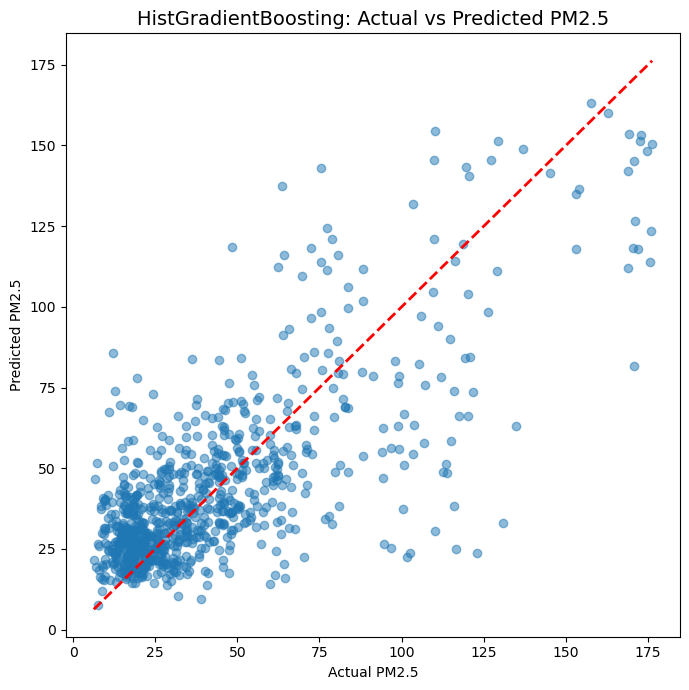

In [56]:
import matplotlib.pyplot as plt;
import seaborn as sns;
plt.figure(figsize=(7,7));
plt.scatter(y_test, y_pred_hgb, alpha=0.5);
plt.plot([y_test.min(), y_test.max()],[y_test.min(),y_test.max()],"r--",linewidth=2);
plt.title("HistGradientBoosting: Actual vs Predicted PM2.5", fontsize=14);
plt.xlabel("Actual PM2.5");
plt.ylabel("Predicted PM2.5");
plt.tight_layout();
plt.show();

C:\Users\HEDWIG\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


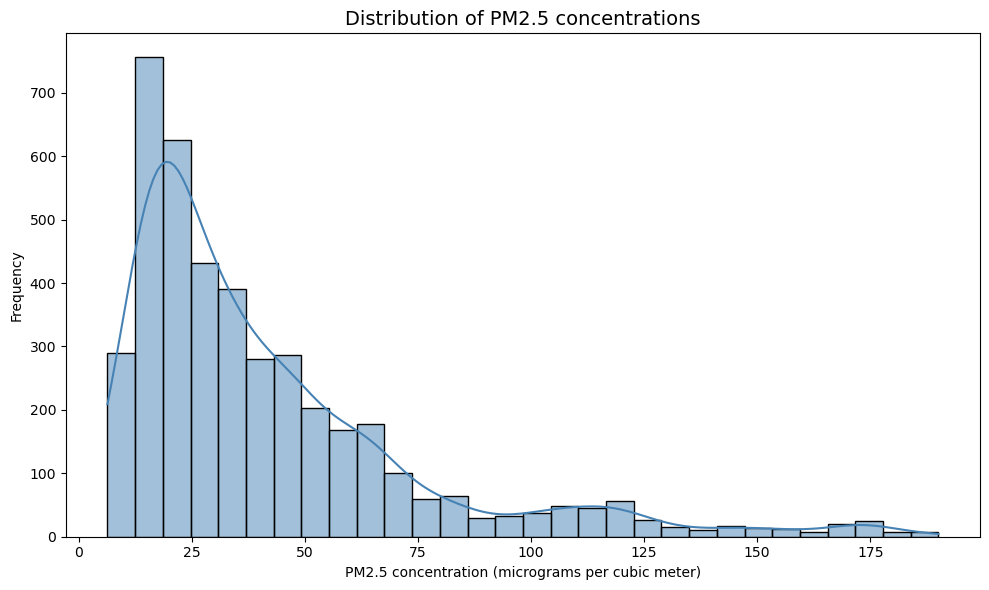

In [219]:
plt.figure(figsize=(10,6));
sns.histplot(
    data=data_clean,
    x="pm25",
    bins=30,
    kde=True,
    color="steelblue"
);
plt.title("Distribution of PM2.5 concentrations",fontsize=14);
plt.xlabel("PM2.5 concentration (micrograms per cubic meter)");
plt.ylabel("Frequency");
plt.tight_layout();
plt.show();

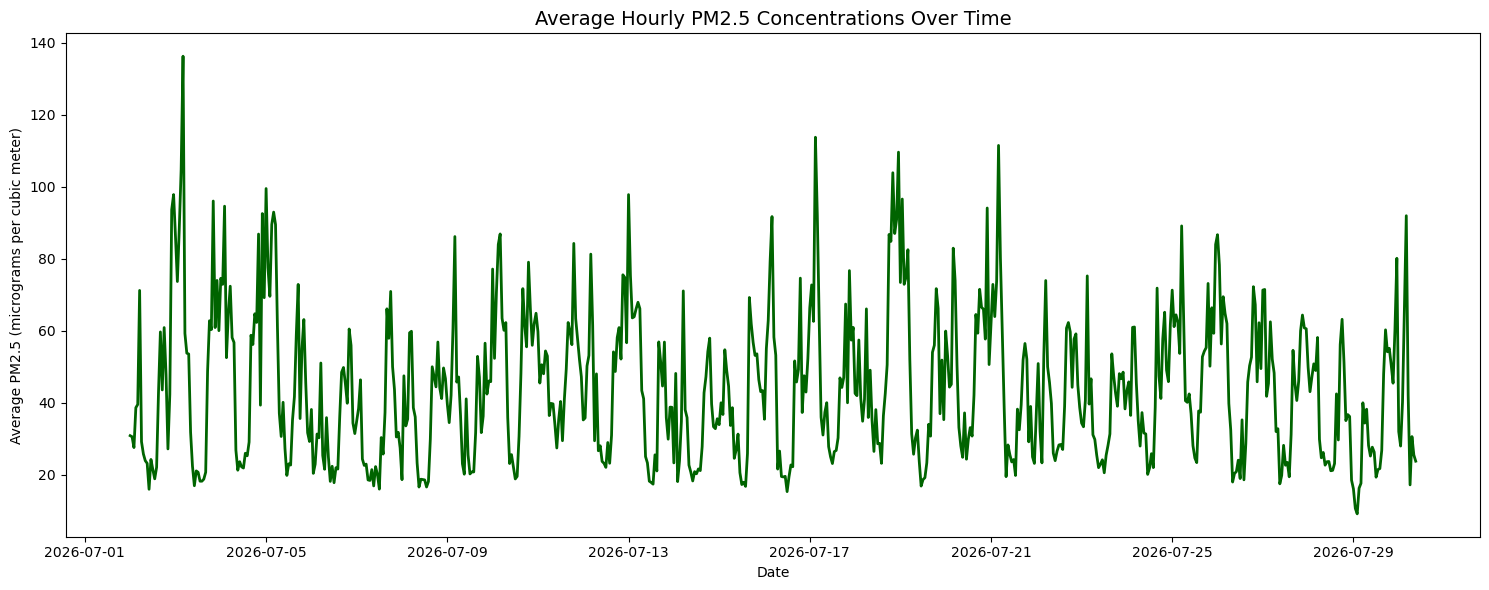

In [233]:
hourly_avg_pm25 = (data_clean.groupby("observation_timestamp")["pm25"].mean().reset_index());

plt.figure(figsize=(15,6));
plt.plot(
    hourly_avg_pm25["observation_timestamp"],
    hourly_avg_pm25["pm25"],
    color="darkgreen",
    linewidth=2
);
plt.title("Average Hourly PM2.5 Concentrations Over Time", fontsize=14);
plt.xlabel("Date");
plt.ylabel("Average PM2.5 (micrograms per cubic meter)");
plt.tight_layout();
plt.show();

In [227]:
# reloading original dataset
airqo_raw = pd.read_json(r"E:\RSXS\Study\project\ParticulateMatterApp\data\ML\standardised_airqo.json");

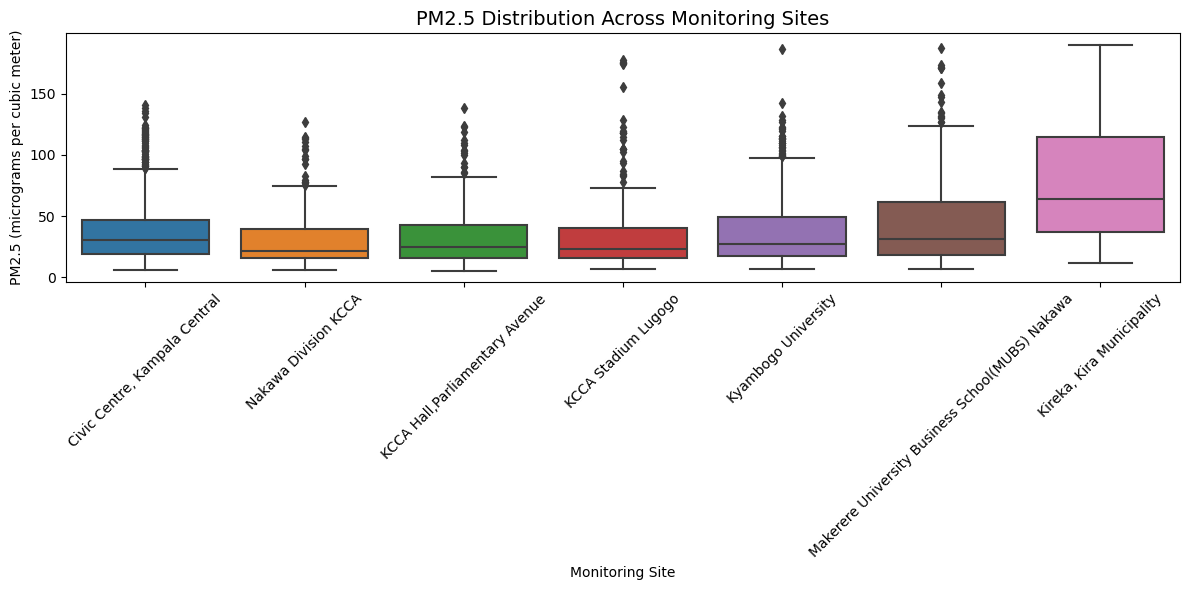

In [229]:
plt.figure(figsize=(12,6));
sns.boxplot(
    data=airqo_raw,
    x="site",
    y="pm25"
);
plt.xticks(rotation=45);
plt.title("PM2.5 Distribution Across Monitoring Sites", fontsize=14)
plt.xlabel("Monitoring Site");
plt.ylabel("PM2.5 (micrograms per cubic meter)");
plt.tight_layout();
plt.show();

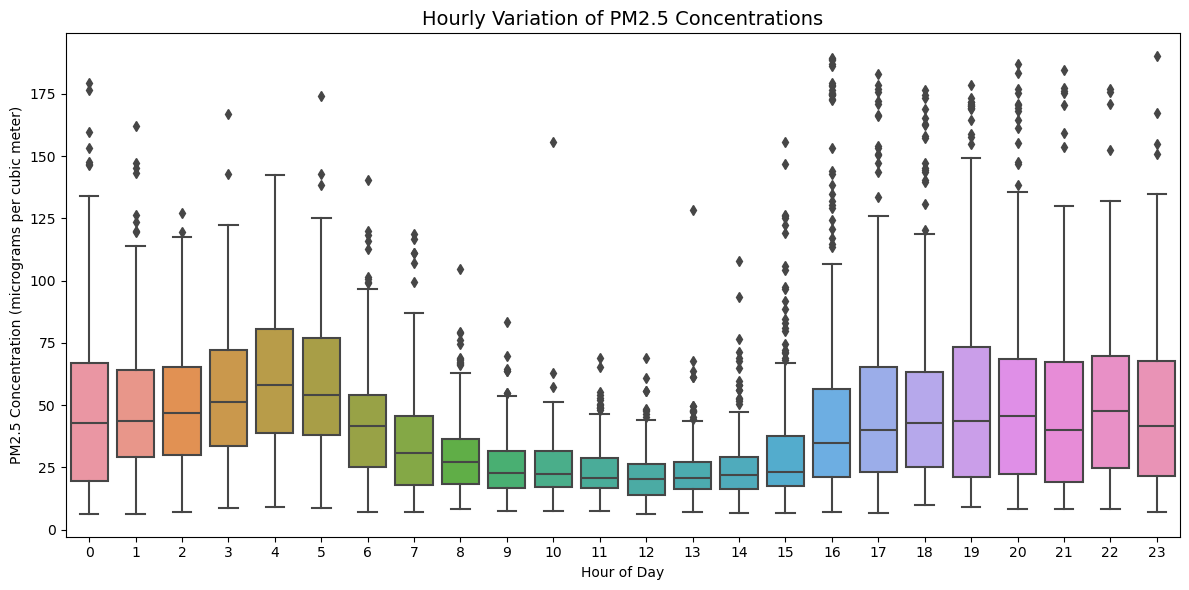

In [235]:
plt.figure(figsize=(12,6));
sns.boxplot(
    data = data_clean,
    x="hour_of_day",
    y="pm25"
);

plt.title("Hourly Variation of PM2.5 Concentrations", fontsize=14);
plt.xlabel("Hour of Day");
plt.ylabel("PM2.5 Concentration (micrograms per cubic meter)");
plt.tight_layout();
plt.show();